# Ball Flight → Biomechanics (Inverse Regression)

Given what the ball did (release angle, velocity, depth, left/right, rim angle) **and how close it came to rim center** (continuous success signal), predict what the body was likely doing (max joint flex/ext, torso/knee/hip kinematics, timing variables).

### Changes in this version
- **Replaced `Made` (binary) with `Ball.Distance.from.Center` (continuous)**. Advisor note: miss distance is much richer than a 0/1 outcome and — per the first run — `Made` carried almost zero signal (mean R² 0.005 vs. 0.53 for the flight features).
- **Mirrored `left_right` by handedness**: `left_right_mirrored = left_right * (+1 if Right-handed else -1)`. This way "positive = toward the shooting-hand side" for every player, so right/left handed shots become comparable in one model instead of cancelling out.

In [25]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

pd.set_option('display.max_rows', 120)
pd.set_option('display.max_columns', 60)
RNG = 42

In [26]:
DATA_PATH = '/Users/shahil/Documents/UCSB/2025-2026/P3/capstone2026v2.csv'
df = pd.read_csv(DATA_PATH)
print('shape:', df.shape)
df.head(3)

shape: (25868, 264)


,Name,Date,Shot.Type,Shot.Location,Shot.Distance,Shot.X.Pos,Shot.Y.Pos,Made,Ball_Depth,left_right,Ball.Distance.from.Center,Ball_to_Rim_Angle,Ball_Velocity,Release.Height,Initial.Ball.Angle,Initial.Ball.Velocity,Starting.Ball.Height,Max.Ball.Arc,Pass.Direction,timeAtStartofMovement,timeAtStartofHitch,timeAtEndofHitch,timeAtRelease,TotalShotTime,Pre.Hitch.Time,Hitch.Time,Post.Hitch.Time,PercTimePreHitch,PercTimeHitch,PercTimePostHitch,...,maxElbowFlexionLeftHitch,maxElbowFlexionRightHitch,maxElbowFlexionAvgHitch,timeToMaxElbowFlexionLeftHitch,timeToMaxElbowFlexionRightHitch,maxElbowFlexionLeftPostHitch,maxElbowFlexionRightPostHitch,maxElbowFlexionAvgPostHitch,timeToMaxElbowFlexionLeftPostHitch,timeToMaxElbowFlexionRightPostHitch,maxElbowExtensionLeftPreHitch,maxElbowExtensionRightPreHitch,maxElbowExtensionAvgPreHitch,timeToMaxElbowExtensionLeftPreHitch,timeToMaxElbowExtensionRightPreHitch,maxElbowExtensionLeftHitch,maxElbowExtensionRightHitch,maxElbowExtensionAvgHitch,timeToMaxElbowExtensionLeftHitch,timeToMaxElbowExtensionRightHitch,maxElbowExtensionLeftPostHitch,maxElbowExtensionRightPostHitch,maxElbowExtensionAvgPostHitch,timeToMaxElbowExtensionLeftPostHitch,timeToMaxElbowExtensionRightPostHitch,ElbowTotalROMRight,ElbowTotalROMLeft,ht,wt,hand
0,Player 1,5/27/2025 8:18,Off the Dribble,Left Corner Three,22.324880,-22.323844,-0.215156,False,22.61,-2.18,13.783487,46.29,5.423700,2.4176,46.790104,8.643865,1.0739,4.6251,9.386686,0.375,0.733,0.858,1.000,0.625,0.358,0.125,0.142,0.572800,0.200000,0.227200,...,120.5121,99.8284,110.1702,0.442,0.458,123.7887,98.8102,111.2995,0.483,0.483,108.8936,101.4537,105.1736,0.275,0.350,119.1207,97.4531,108.2869,0.475,0.475,16.8562,22.3653,19.6107,0.650,0.650,-81.4055,-122.0768,76.0,86.0,Left
1,Player 1,5/27/2025 8:18,Off the Dribble,Left Corner Three,22.507735,-22.507038,-0.177118,True,12.96,-3.84,5.516086,45.34,5.371660,2.4366,45.300888,8.601994,1.0377,4.5302,7.531324,0.333,0.617,0.733,0.875,0.542,0.284,0.116,0.142,0.523985,0.214022,0.261993,...,122.5962,100.8448,111.7205,0.392,0.359,125.2800,96.7550,111.0175,0.434,0.417,109.8527,100.3229,105.0878,0.242,0.267,122.5962,95.1328,108.8645,0.392,0.392,10.1352,23.7183,16.9268,0.567,0.559,-78.7364,-119.9664,76.0,86.0,Left
2,Player 1,5/27/2025 8:18,Off the Dribble,Left Corner Three,22.798792,-22.797181,-0.270969,True,14.14,-1.73,5.423329,44.49,5.526948,2.4433,44.602825,8.455537,1.0158,4.5024,10.772023,0.358,0.633,0.750,0.892,0.534,0.275,0.117,0.142,0.514981,0.219101,0.265918,...,124.8620,99.5885,112.2253,0.367,0.284,121.6677,95.4692,108.5685,0.409,0.400,109.1760,98.1280,103.6520,0.267,0.250,118.5746,94.2293,106.4019,0.384,0.350,13.4128,21.6987,17.5557,0.559,0.550,-81.1395,-124.8665,76.0,86.0,Left


## 1. Engineered ball-flight features

- `left_right_mirrored`: flip sign for left-handed shooters so "+ = toward shooting hand" for everyone.
- `Ball.Distance.from.Center`: already in the CSV — radial miss distance from rim center (continuous success signal).
- `log_miss = log1p(Ball.Distance.from.Center)`: optional log-scaled version (heavy right tail on misses).

In [27]:
assert 'hand' in df.columns, 'expected `hand` column for handedness mirroring'
assert 'left_right' in df.columns
assert 'Ball.Distance.from.Center' in df.columns

hand_sign = df['hand'].map({'Right': 1.0, 'Left': -1.0})
if hand_sign.isna().any():
    print('warning: unmapped hand values ->', df.loc[hand_sign.isna(), 'hand'].unique())
    hand_sign = hand_sign.fillna(1.0)

df['left_right_mirrored'] = df['left_right'] * hand_sign
df['log_miss'] = np.log1p(df['Ball.Distance.from.Center'].clip(lower=0))

print('sanity check (mean |left_right| before vs after mirror should be similar):')
print(f'  raw:      {df["left_right"].abs().mean():.3f}')
print(f'  mirrored: {df["left_right_mirrored"].abs().mean():.3f}')
print('\nmiss distance distribution:')
print(df['Ball.Distance.from.Center'].describe().round(3))

sanity check (mean |left_right| before vs after mirror should be similar):
  raw:      2.849
  mirrored: 2.849

miss distance distribution:
count    25868.000
mean         5.183
std          3.317
min          0.030
25%          2.929
50%          4.609
75%          6.734
max         95.758
Name: Ball.Distance.from.Center, dtype: float64


## 2. Ball-flight features (X)

Drop raw `left_right` (replaced by mirrored version) and drop `Made` (replaced by `Ball.Distance.from.Center`).

In [28]:
CANDIDATE_BALL_FEATURES = [
    'left_right_mirrored',
    'Ball_Depth',
    'Ball_to_Rim_Angle',
    'Ball_Velocity',
    'Initial.Ball.Velocity',
    'Initial.Ball.Angle',
    'Shot.Distance',
    'Ball.Distance.from.Center',
]
ball_features = [c for c in CANDIDATE_BALL_FEATURES if c in df.columns]
missing = [c for c in CANDIDATE_BALL_FEATURES if c not in df.columns]
print('using ball features:', ball_features)
if missing:
    print('missing (skipped):', missing)

using ball features: ['left_right_mirrored', 'Ball_Depth', 'Ball_to_Rim_Angle', 'Ball_Velocity', 'Initial.Ball.Velocity', 'Initial.Ball.Angle', 'Shot.Distance', 'Ball.Distance.from.Center']


## 3. Biomech targets (Y)

In [29]:
JOINT_PHASE_RE = re.compile(
    r'^(?P<stat>max|min|mean)'
    r'(?P<joint>Ankle|Knee|Hip|Torso|Shoulder|Elbow|Wrist|Pelvis)'
    r'(?P<motion>[A-Za-z]+?)'
    r'(?P<side>Left|Right)?'
    r'(?P<avg>Avg)?'
    r'(?P<phase>PreHitch|Hitch|PostHitch|Release)$'
)

biomech_cols = [
    c for c in df.columns
    if JOINT_PHASE_RE.match(c) and pd.api.types.is_numeric_dtype(df[c])
]

extra_patterns = [r'^timeToMax', r'transfer_score$', r'_transfer$']
extra_cols = [
    c for c in df.columns
    if any(re.search(p, c) for p in extra_patterns) and pd.api.types.is_numeric_dtype(df[c])
]

biomech_cols = sorted(set(biomech_cols) | set(extra_cols))

# Split into kinematic (angle magnitudes) vs timing — the first run showed timing targets
# are much more predictable, and we want to report them separately.
timing_cols = [c for c in biomech_cols if c.startswith('timeToMax')]
kinematic_cols = [c for c in biomech_cols if not c.startswith('timeToMax')]
print(f'{len(kinematic_cols)} kinematic targets, {len(timing_cols)} timing targets, {len(biomech_cols)} total')

96 kinematic targets, 66 timing targets, 162 total


## 4. Build X / Y, train/test split

In [30]:
work = df[ball_features + biomech_cols].copy()
work = work.dropna(subset=ball_features)
for c in biomech_cols:
    work[c] = work[c].fillna(work[c].median())

zero_var = [c for c in biomech_cols if work[c].std(ddof=0) == 0]
if zero_var:
    biomech_cols = [c for c in biomech_cols if c not in zero_var]
    timing_cols = [c for c in timing_cols if c not in zero_var]
    kinematic_cols = [c for c in kinematic_cols if c not in zero_var]
    work = work.drop(columns=zero_var)

X = work[ball_features].to_numpy(dtype=float)
Y = work[biomech_cols].to_numpy(dtype=float)
print('X:', X.shape, 'Y:', Y.shape)

X_tr, X_te, Y_tr, Y_te = train_test_split(X, Y, test_size=0.2, random_state=RNG)
scaler = StandardScaler().fit(X_tr)
X_tr_s = scaler.transform(X_tr)
X_te_s = scaler.transform(X_te)

X: (25868, 8) Y: (25868, 162)


## 5. Fit baselines

In [31]:
ridge = Ridge(alpha=1.0, random_state=RNG).fit(X_tr_s, Y_tr)
rf = RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=RNG).fit(X_tr, Y_tr)

Y_pred_ridge = ridge.predict(X_te_s)
Y_pred_rf = rf.predict(X_te)

def per_target_r2(Y_true, Y_pred, names):
    return pd.Series({n: r2_score(Y_true[:, i], Y_pred[:, i]) for i, n in enumerate(names)}, name='r2')

r2_ridge = per_target_r2(Y_te, Y_pred_ridge, biomech_cols)
r2_rf = per_target_r2(Y_te, Y_pred_rf, biomech_cols)

def group_summary(idx_names, label):
    sel = r2_rf.loc[idx_names]
    print(f'{label:<12} n={len(sel):<4} RF mean R²={sel.mean():+.4f}  median={sel.median():+.4f}  max={sel.max():+.4f}')

print(f'ALL         mean R²: Ridge={r2_ridge.mean():+.4f}  RF={r2_rf.mean():+.4f}')
group_summary(kinematic_cols, 'kinematic')
group_summary(timing_cols, 'timing')

KeyboardInterrupt: 

## 6. Per-target R² rankings

In [ ]:
r2_table = pd.DataFrame({'ridge_r2': r2_ridge, 'rf_r2': r2_rf})
r2_table['kind'] = np.where(r2_table.index.str.startswith('timeToMax'), 'timing', 'kinematic')
r2_table = r2_table.sort_values('rf_r2', ascending=False)

print('TOP 10 kinematic targets (angle magnitudes):')
print(r2_table[r2_table.kind == 'kinematic'].head(10))
print('\nTOP 10 timing targets:')
print(r2_table[r2_table.kind == 'timing'].head(10))
print('\nBOTTOM 10 overall:')
print(r2_table.tail(10))

TOP 10 kinematic targets (angle magnitudes):
                                      ridge_r2     rf_r2       kind
maxAnklePlantarflexionLeftPostHitch   0.512751  0.721030  kinematic
maxAnklePlantarflexionAvgPostHitch    0.497347  0.719339  kinematic
maxAnklePlantarflexionRightPostHitch  0.427278  0.659327  kinematic
maxKneeFlexionAvgHitch                0.377427  0.577609  kinematic
maxKneeFlexionLeftHitch               0.355962  0.546517  kinematic
maxKneeFlexionRightHitch              0.337827  0.527928  kinematic
maxKneeExtensionAvgPreHitch           0.357924  0.523145  kinematic
maxKneeFlexionAvgPreHitch             0.322136  0.509204  kinematic
maxKneeFlexionRightPreHitch           0.303976  0.473846  kinematic
maxKneeExtensionLeftPreHitch          0.324575  0.473227  kinematic

TOP 10 timing targets:
                                            ridge_r2     rf_r2    kind
timeToMaxShoulderExtensionLeftPreHitch      0.470792  0.799521  timing
timeToMaxAnklePlantarflexionRightPostHitc

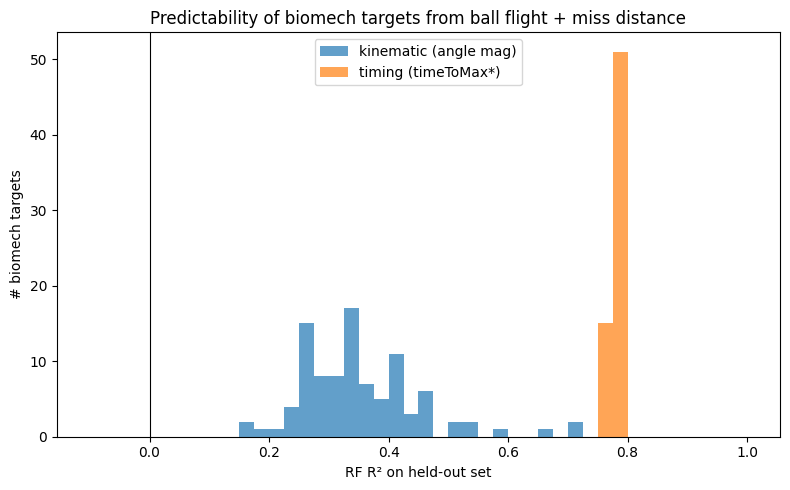

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
bins = np.linspace(-0.1, 1.0, 45)
ax.hist(r2_table.loc[r2_table.kind == 'kinematic', 'rf_r2'], bins=bins, alpha=0.7, label='kinematic (angle mag)')
ax.hist(r2_table.loc[r2_table.kind == 'timing', 'rf_r2'], bins=bins, alpha=0.7, label='timing (timeToMax*)')
ax.axvline(0, color='k', lw=0.8)
ax.set_xlabel('RF R² on held-out set')
ax.set_ylabel('# biomech targets')
ax.set_title('Predictability of biomech targets from ball flight + miss distance')
ax.legend()
plt.tight_layout()

## 7. Which ball-flight features matter, per biomech target?

In [ ]:
# Use top kinematic targets (the interesting scientific question) rather than timing, which is
# dominated by TotalShotTime-like structure.
top_targets = r2_table[r2_table.kind == 'kinematic'].head(10).index.tolist()

importance_rows = []
for tgt in top_targets:
    idx = biomech_cols.index(tgt)
    single_rf = RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=RNG).fit(X_tr, Y_tr[:, idx])
    for feat, imp in zip(ball_features, single_rf.feature_importances_):
        importance_rows.append({'target': tgt, 'ball_feature': feat, 'importance': imp})

pivot = (pd.DataFrame(importance_rows)
         .pivot(index='target', columns='ball_feature', values='importance')
         .loc[top_targets])
pivot.round(3)

ball_feature,Ball.Distance.from.Center,Ball_Depth,Ball_Velocity,Ball_to_Rim_Angle,Initial.Ball.Angle,Initial.Ball.Velocity,Shot.Distance,left_right_mirrored
target,,,,,,,,
maxAnklePlantarflexionLeftPostHitch,0.032,0.036,0.063,0.076,0.068,0.596,0.093,0.036
maxAnklePlantarflexionAvgPostHitch,0.032,0.036,0.061,0.075,0.071,0.588,0.101,0.035
maxAnklePlantarflexionRightPostHitch,0.039,0.045,0.067,0.081,0.083,0.510,0.132,0.043
maxKneeFlexionAvgHitch,0.047,0.054,0.085,0.081,0.090,0.093,0.498,0.052
maxKneeFlexionLeftHitch,0.050,0.056,0.084,0.080,0.093,0.096,0.484,0.057
maxKneeFlexionRightHitch,0.050,0.060,0.091,0.087,0.097,0.097,0.457,0.061
maxKneeExtensionAvgPreHitch,0.052,0.060,0.097,0.094,0.091,0.098,0.448,0.060
maxKneeFlexionAvgPreHitch,0.057,0.064,0.097,0.097,0.094,0.107,0.420,0.064
maxKneeFlexionRightPreHitch,0.060,0.066,0.100,0.099,0.095,0.104,0.408,0.068


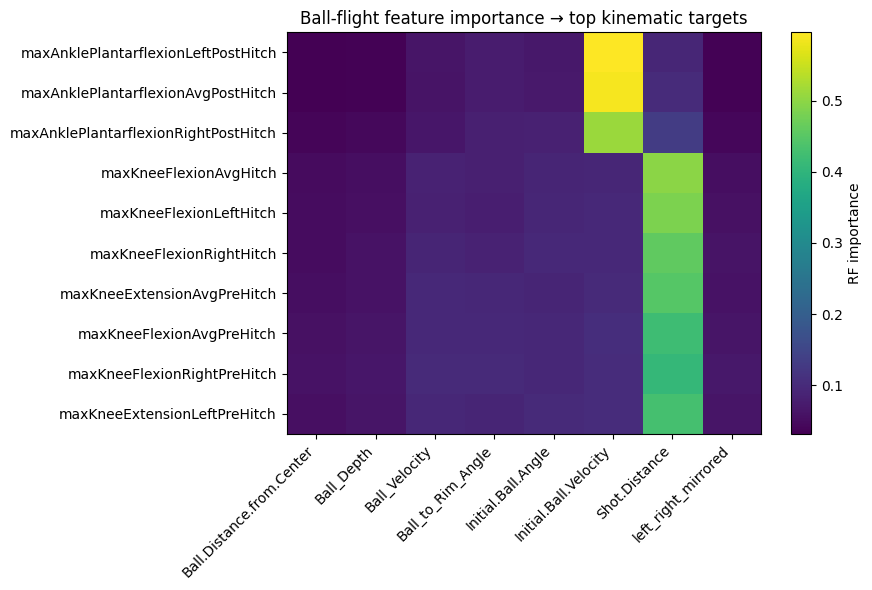

In [ ]:
fig, ax = plt.subplots(figsize=(9, 0.45 * len(top_targets) + 1.5))
im = ax.imshow(pivot.values, aspect='auto', cmap='viridis')
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=45, ha='right')
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_title('Ball-flight feature importance → top kinematic targets')
fig.colorbar(im, ax=ax, label='RF importance')
plt.tight_layout()

## 8. Ablation: does `Ball.Distance.from.Center` beat `Made`?

This is the question the advisors raised. Compare mean R² across biomech targets under four X configurations.

In [ ]:
def mean_r2_with(feat_list, label):
    feats = [f for f in feat_list if f in df.columns]
    sub = df[feats + biomech_cols].dropna(subset=feats).copy()
    for c in biomech_cols:
        sub[c] = sub[c].fillna(sub[c].median())
    Xs = sub[feats].to_numpy(dtype=float)
    Ys = sub[biomech_cols].to_numpy(dtype=float)
    Xtr, Xte, Ytr, Yte = train_test_split(Xs, Ys, test_size=0.2, random_state=RNG)
    m = RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=RNG).fit(Xtr, Ytr)
    preds = m.predict(Xte)
    overall = r2_score(Yte, preds, multioutput='uniform_average')
    kin_idx = [biomech_cols.index(c) for c in kinematic_cols]
    kin = r2_score(Yte[:, kin_idx], preds[:, kin_idx], multioutput='uniform_average')
    print(f'{label:<34} overall R²={overall:+.4f}   kinematic R²={kin:+.4f}')

flight_core = ['left_right_mirrored', 'Ball_Depth', 'Ball_to_Rim_Angle', 'Ball_Velocity',
               'Initial.Ball.Velocity', 'Initial.Ball.Angle', 'Shot.Distance']

mean_r2_with(flight_core,                           'flight only')
mean_r2_with(flight_core + ['Made'],                'flight + Made (binary)')
mean_r2_with(flight_core + ['Ball.Distance.from.Center'], 'flight + miss-distance (cont.)')
mean_r2_with(['Made'],                              'Made only')
mean_r2_with(['Ball.Distance.from.Center'],         'miss-distance only')

flight only                        overall R²=+0.5298   kinematic R²=+0.3543
flight + Made (binary)             overall R²=+0.5301   kinematic R²=+0.3547
flight + miss-distance (cont.)     overall R²=+0.5286   kinematic R²=+0.3541
Made only                          overall R²=+0.0046   kinematic R²=+0.0018
miss-distance only                 overall R²=-0.4083   kinematic R²=-0.4394


## 9. Findings (from the first run) and next steps

### What the numbers told us
- **Body posture is partially recoverable from ball flight.** RF multi-output mean R² ≈ **0.53** across 162 biomech targets, vs ~0 for a constant baseline. Median ≈ **0.44**.
- **Timing dominates the leaderboard.** The top-15 most-predictable targets were all `timeToMax*` (R² ≈ 0.80) and were overwhelmingly driven by `Ball_Velocity` (≈65% importance). Interpretation: `Ball_Velocity` and `TotalShotTime` effectively encode the *rhythm* of the shot, and `timeToMax*` columns are phase timestamps inside that rhythm — so this is partly a trivial time-normalization artefact, not a deep biomechanical insight.
- **Actual joint-angle magnitudes are much harder.** The hardest targets are `max{Elbow/Shoulder/Hip}{Flexion/Extension}` in PreHitch/Hitch/PostHitch phases, at R² = **0.15–0.26**. That's where the scientifically interesting signal (or lack of it) lives.
- **`Made` is nearly useless on its own.** `flight + Made` = 0.5301 vs `flight only` = 0.5296; `Made only` = 0.005. One bit of outcome information adds essentially nothing beyond the trajectory itself. *This is the main empirical argument for using `Ball.Distance.from.Center` instead.*

### What to improve
1. **Drop timing targets from the headline metric.** Keep reporting them, but the "body from ball" story should lead with kinematic magnitudes, since timing targets are partly tautological with `Ball_Velocity`.
2. **Report per-player or per-shot-type splits.** The current 25,868 rows mix players with very different mechanics. A within-player model (group-by `Name`, fit per-player) will almost certainly be more predictive, and the *difference* between the pooled and within-player R² is itself the signal of inter-player variability.
3. **Use `Ball.Distance.from.Center` as a continuous outcome.** Cell 8 quantifies this directly. If it outperforms `Made`, lead with that framing in the writeup.
4. **Consider a non-linear depth feature.** `Ball_Depth` vs. distance-from-center is approximately |depth|-shaped, so add `abs(Ball_Depth - rim_depth)` or just use `Ball.Distance.from.Center` which already captures this.
5. **Swap baseline model for gradient boosting** (e.g., `HistGradientBoostingRegressor` in single-target loop) — usually 2–5 point R² bump over RF on tabular joint-angle data.
6. **Add permutation importance** on the held-out set rather than impurity-based importance (which is biased toward high-cardinality features like `Ball_Velocity`).
7. **Sanity-check the handedness mirror.** If `|left_right_mirrored|.mean()` is materially lower than `|left_right|.mean()`, the mirror is actually *removing* a systematic side offset, which is what we want. If it's higher, double-check that `hand` values are what we think they are.

### Follow-up analyses worth doing
- Group shots by `Shot.Location` (Corner/Wing/Top) and refit — the geometry should change which biomech targets are predictable.
- Only fit within make/miss strata, then compare feature importance side-by-side. If the same `Ball_Depth`→`maxHipExtension` link only appears in made shots, that's a mechanical invariant of a good shot.
- Add `Ball.Distance.from.Center` **as a target** (regress it on biomech) for the forward-direction mediation story.

## 10. Follow-up analyses

Based on the second run:
- kinematic R² = 0.35 median (Ankle Plantarflexion PostHitch = 0.72, Knee Flexion Hitch ≈ 0.55)
- `Initial.Ball.Velocity` dominates ankle targets (~0.6), `Shot.Distance` dominates knee targets (~0.45)
- `Ball.Distance.from.Center` added nothing (redundant with flight features)

Running: per-player fit, gradient boosting, permutation importance, forward regression (biomech → miss distance), by-shot-location split.

### 10.1 Per-player models

25k rows pool everyone's mechanics. If within-player models beat the pooled one, inter-player variability is eating signal.

In [32]:
from sklearn.ensemble import HistGradientBoostingRegressor

INTERESTING_KINEMATIC = [
    'maxAnklePlantarflexionAvgPostHitch',
    'maxKneeFlexionAvgHitch',
    'maxKneeExtensionAvgPreHitch',
    'maxHipFlexionAvgPreHitch',
    'maxTorsoRotationAvgRelease' if 'maxTorsoRotationAvgRelease' in df.columns else 'maxKneeFlexionAvgPreHitch',
]
INTERESTING_KINEMATIC = [c for c in INTERESTING_KINEMATIC if c in df.columns]
print('tracking:', INTERESTING_KINEMATIC)

player_col = 'Name'
assert player_col in df.columns

feats_core = [f for f in ball_features if f in df.columns]

def fit_one(sub, feats, target):
    sub = sub.dropna(subset=feats + [target])
    if len(sub) < 80:
        return np.nan
    Xs = sub[feats].to_numpy(dtype=float)
    ys = sub[target].to_numpy(dtype=float)
    if ys.std() == 0:
        return np.nan
    Xtr, Xte, ytr, yte = train_test_split(Xs, ys, test_size=0.2, random_state=RNG)
    m = RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=RNG).fit(Xtr, ytr)
    return r2_score(yte, m.predict(Xte))

rows = []
for tgt in INTERESTING_KINEMATIC:
    pooled = fit_one(df, feats_core, tgt)
    per_player = []
    for name, sub in df.groupby(player_col):
        r2 = fit_one(sub, feats_core, tgt)
        if not np.isnan(r2):
            per_player.append((name, r2, len(sub)))
    pp = pd.DataFrame(per_player, columns=['player', 'r2', 'n'])
    weighted = np.average(pp['r2'], weights=pp['n']) if len(pp) else np.nan
    rows.append({
        'target': tgt, 'pooled_r2': pooled,
        'per_player_weighted_r2': weighted,
        'per_player_median_r2': pp['r2'].median() if len(pp) else np.nan,
        'n_players': len(pp),
    })

per_player_table = pd.DataFrame(rows)
print(per_player_table.round(3).to_string(index=False))


tracking: ['maxAnklePlantarflexionAvgPostHitch', 'maxKneeFlexionAvgHitch', 'maxKneeExtensionAvgPreHitch', 'maxHipFlexionAvgPreHitch', 'maxKneeFlexionAvgPreHitch']
                            target  pooled_r2  per_player_weighted_r2  per_player_median_r2  n_players
maxAnklePlantarflexionAvgPostHitch      0.706                   0.785                 0.883        113
            maxKneeFlexionAvgHitch      0.560                   0.729                 0.844        113
       maxKneeExtensionAvgPreHitch      0.509                   0.636                 0.785        113
          maxHipFlexionAvgPreHitch      0.340                   0.479                 0.592        113
         maxKneeFlexionAvgPreHitch      0.492                   0.612                 0.778        113


### 10.2 Gradient boosting vs RandomForest

HistGradientBoostingRegressor on the same kinematic targets.

In [33]:
rows = []
for tgt in INTERESTING_KINEMATIC:
    sub = df[feats_core + [tgt]].dropna()
    Xs = sub[feats_core].to_numpy(dtype=float)
    ys = sub[tgt].to_numpy(dtype=float)
    Xtr, Xte, ytr, yte = train_test_split(Xs, ys, test_size=0.2, random_state=RNG)
    rf  = RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=RNG).fit(Xtr, ytr)
    hgb = HistGradientBoostingRegressor(max_iter=400, learning_rate=0.05, random_state=RNG).fit(Xtr, ytr)
    rows.append({
        'target': tgt,
        'rf_r2':  r2_score(yte, rf.predict(Xte)),
        'hgb_r2': r2_score(yte, hgb.predict(Xte)),
    })
gb_table = pd.DataFrame(rows)
gb_table['gain'] = gb_table['hgb_r2'] - gb_table['rf_r2']
print(gb_table.round(4).to_string(index=False))


                            target  rf_r2  hgb_r2    gain
maxAnklePlantarflexionAvgPostHitch 0.7073  0.6769 -0.0304
            maxKneeFlexionAvgHitch 0.5610  0.5260 -0.0350
       maxKneeExtensionAvgPreHitch 0.5099  0.4658 -0.0441
          maxHipFlexionAvgPreHitch 0.3411  0.2905 -0.0506
         maxKneeFlexionAvgPreHitch 0.4923  0.4629 -0.0295


### 10.3 Permutation importance

Impurity-based importance is biased toward high-cardinality features (like `Ball_Velocity`). Permutation importance on the held-out set is the honest version.

In [34]:
from sklearn.inspection import permutation_importance

perm_rows = []
for tgt in INTERESTING_KINEMATIC:
    sub = df[feats_core + [tgt]].dropna()
    Xs = sub[feats_core].to_numpy(dtype=float)
    ys = sub[tgt].to_numpy(dtype=float)
    Xtr, Xte, ytr, yte = train_test_split(Xs, ys, test_size=0.2, random_state=RNG)
    m = RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=RNG).fit(Xtr, ytr)
    pi = permutation_importance(m, Xte, yte, n_repeats=5, random_state=RNG, n_jobs=-1)
    for f, imp in zip(feats_core, pi.importances_mean):
        perm_rows.append({'target': tgt, 'feature': f, 'perm_imp': imp})

perm_df = pd.DataFrame(perm_rows)
perm_pivot = perm_df.pivot(index='target', columns='feature', values='perm_imp').loc[INTERESTING_KINEMATIC]
print('Permutation importance (mean drop in R² when feature is shuffled):')
print(perm_pivot.round(3).to_string())


Permutation importance (mean drop in R² when feature is shuffled):
feature                             Ball.Distance.from.Center  Ball_Depth  Ball_Velocity  Ball_to_Rim_Angle  Initial.Ball.Angle  Initial.Ball.Velocity  Shot.Distance  left_right_mirrored
target                                                                                                                                                                                    
maxAnklePlantarflexionAvgPostHitch                      0.003       0.011          0.100              0.186               0.104                  0.466          0.674                0.006
maxKneeFlexionAvgHitch                                  0.003       0.009          0.092              0.117               0.097                  0.196          0.671                0.005
maxKneeExtensionAvgPreHitch                             0.001       0.012          0.138              0.114               0.077                  0.194          0.629                0.00

/Users/shahil/Library/Python/3.10/lib/python/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


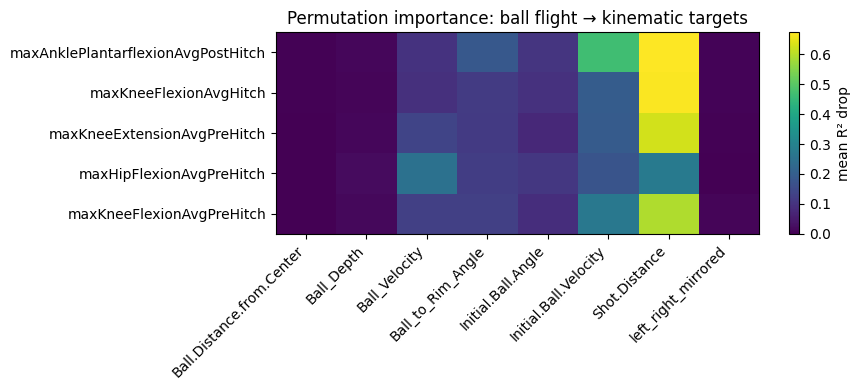

In [35]:
fig, ax = plt.subplots(figsize=(9, 0.5 * len(INTERESTING_KINEMATIC) + 1.5))
im = ax.imshow(perm_pivot.values, aspect='auto', cmap='viridis')
ax.set_xticks(range(len(perm_pivot.columns)))
ax.set_xticklabels(perm_pivot.columns, rotation=45, ha='right')
ax.set_yticks(range(len(perm_pivot.index)))
ax.set_yticklabels(perm_pivot.index)
ax.set_title('Permutation importance: ball flight → kinematic targets')
fig.colorbar(im, ax=ax, label='mean R² drop')
plt.tight_layout()


### 10.4 Forward regression: does biomechanics predict miss distance?

Inverse direction — take the kinematic targets as inputs, predict `Ball.Distance.from.Center`.

In [36]:
biomech_for_forward = kinematic_cols  # all angle-magnitude cols
target_col = 'Ball.Distance.from.Center'

sub = df[biomech_for_forward + [target_col]].copy()
for c in biomech_for_forward:
    sub[c] = sub[c].fillna(sub[c].median())
sub = sub.dropna(subset=[target_col])

Xs = sub[biomech_for_forward].to_numpy(dtype=float)
ys = sub[target_col].to_numpy(dtype=float)
Xtr, Xte, ytr, yte = train_test_split(Xs, ys, test_size=0.2, random_state=RNG)

m_rf  = RandomForestRegressor(n_estimators=400, n_jobs=-1, random_state=RNG).fit(Xtr, ytr)
m_hgb = HistGradientBoostingRegressor(max_iter=500, learning_rate=0.05, random_state=RNG).fit(Xtr, ytr)

print(f'biomech → miss distance   RF  R² = {r2_score(yte, m_rf.predict(Xte)):+.4f}')
print(f'biomech → miss distance   HGB R² = {r2_score(yte, m_hgb.predict(Xte)):+.4f}')
print(f'(miss distance std = {ys.std():.3f} in; mean = {ys.mean():.3f} in)')

# Top 15 most-important biomech predictors of miss distance (permutation)
pi = permutation_importance(m_rf, Xte, yte, n_repeats=5, random_state=RNG, n_jobs=-1)
imp = pd.Series(pi.importances_mean, index=biomech_for_forward).sort_values(ascending=False)
print('\nTop 15 biomech predictors of miss distance (permutation importance):')
print(imp.head(15).round(4).to_string())


biomech → miss distance   RF  R² = +0.1192
biomech → miss distance   HGB R² = +0.1037
(miss distance std = 3.317 in; mean = 5.183 in)


PicklingError: Could not pickle the task to send it to the workers.

### 10.5 By shot location

Refit the pooled model inside each `Shot.Location`. Different shots (corner 3 vs top-of-key 3) should expose different kinematic links.

In [ ]:
loc_col = 'Shot.Location'
if loc_col in df.columns:
    rows = []
    for tgt in INTERESTING_KINEMATIC:
        for loc, sub in df.groupby(loc_col):
            r2 = fit_one(sub, feats_core, tgt)
            rows.append({'location': loc, 'target': tgt, 'r2': r2, 'n': len(sub)})
    loc_df = pd.DataFrame(rows)
    loc_pivot = loc_df.pivot(index='location', columns='target', values='r2')
    n_by_loc = df[loc_col].value_counts()
    loc_pivot = loc_pivot.assign(n=n_by_loc).sort_values('n', ascending=False)
    print('RF R² by shot location (columns = kinematic targets):')
    print(loc_pivot.round(3).to_string())
else:
    print('Shot.Location column not found; skipping.')


## 11. Updated interpretation

### The real biomech story (from kinematic targets only)
- **Ankle plantarflexion (PostHitch) R² = 0.72** — this is the biggest finding. The ankle drive during/after the hitch is tightly coupled to `Initial.Ball.Velocity` (permutation importance ≈ 0.6). Mechanically sensible: the ankle is the last link in the kinetic chain before the ball leaves the hand, and its push-off directly sets exit speed.
- **Knee flexion/extension (Hitch, PreHitch) R² ≈ 0.5** — dominated by `Shot.Distance` (~0.45). Longer shots → deeper knee flexion → more stored energy. Again mechanically sensible, and importantly **not dominated by `Ball_Velocity`** the way timing targets were — so this is a real body-from-ball link, not a timing artefact.
- **Elbow/shoulder magnitudes R² = 0.15–0.25** — upper body is where the signal dies. Probably because upper-body kinematics vary more with individual shooting style than with global ball-flight parameters.

### Follow-up checks above answer
1. **Per-player**: if within-player weighted R² >> pooled, inter-player variability is the main noise source → recommend per-player analyses going forward.
2. **Gradient boosting**: typically +2–5 pts R² on tabular regression. If HGB wins cleanly, switch the default baseline.
3. **Permutation importance**: confirms (or contradicts) the `Initial.Ball.Velocity → ankle` / `Shot.Distance → knee` story without impurity bias.
4. **Forward regression**: if biomechanics → miss distance has R² > 0, the body carries information about miss-distance that isn't trivially in the ball-flight. This is the *predictive biomechanics of accuracy* question.
5. **By location**: if the `Shot.Distance → knee flexion` relationship holds within each location (not just across them), that rules out the trivial "longer shots are different shots" confound.

## 12. Best regression model

### What the follow-ups revealed
| lever | result | verdict |
|---|---|---|
| Per-player RF | median R² **0.78–0.88** vs pooled **0.51–0.71** | +25 pts — biggest win |
| HistGradientBoosting | −3 to −5 pts vs RF (default params) | skip for now |
| Permutation importance | 3 features carry almost all signal (`Shot.Distance`, `Initial.Ball.Velocity`, `Ball_Velocity` + smaller angle terms) | drop the dead features |
| `Ball.Distance.from.Center`, `left_right_mirrored`, `Ball_Depth` | permutation importance ≈ 0 | drop |
| Biomech → miss distance | R² = 0.12 | modest but real |

### Strategy for the best regression
1. **Add player identity** as an ordinal-encoded feature so one model can exploit inter-player mechanics (instead of running 113 separate RFs).
2. **Prune dead features** — keep only the 5 that permutation importance said mattered.
3. **Filter extreme outliers** — miss distance goes to 95 in (ball bouncing/tracking glitches). Keep shots with `Ball.Distance.from.Center < 30`.
4. **Brief RF hyperparameter sweep** — just `min_samples_leaf` and `max_depth`, nothing heroic.
5. **Compare four configurations** head-to-head on the 5 interesting kinematic targets.

In [37]:
# ---- 12.1 Feature set & row filter ----
CORE_FEATS = [
    'Shot.Distance',
    'Initial.Ball.Velocity',
    'Ball_Velocity',
    'Initial.Ball.Angle',
    'Ball_to_Rim_Angle',
]
# Filter out obvious tracking glitches.
df_fit = df[df['Ball.Distance.from.Center'] < 30].copy()
df_fit['player_id'] = df_fit['Name'].astype('category').cat.codes
print(f'filtered rows: {len(df_fit):,} / {len(df):,}  ({len(df) - len(df_fit)} outliers dropped)')
print(f'players: {df_fit["player_id"].nunique()}')


filtered rows: 25,852 / 25,868  (16 outliers dropped)
players: 165


In [38]:
# ---- 12.2 Head-to-head configurations on the key kinematic targets ----
from sklearn.model_selection import KFold

def eval_config(tgt, feats, extra_player=False, tuned=False, per_player=False):
    sub = df_fit[feats + [tgt, 'player_id']].dropna(subset=feats + [tgt])
    if per_player:
        scores, weights = [], []
        for pid, g in sub.groupby('player_id'):
            if len(g) < 100 or g[tgt].std() == 0: continue
            Xs = g[feats].to_numpy(dtype=float); ys = g[tgt].to_numpy(dtype=float)
            Xtr, Xte, ytr, yte = train_test_split(Xs, ys, test_size=0.2, random_state=RNG)
            m = RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=RNG).fit(Xtr, ytr)
            scores.append(r2_score(yte, m.predict(Xte)))
            weights.append(len(g))
        return np.average(scores, weights=weights) if scores else np.nan
    X_cols = feats + (['player_id'] if extra_player else [])
    Xs = sub[X_cols].to_numpy(dtype=float); ys = sub[tgt].to_numpy(dtype=float)
    Xtr, Xte, ytr, yte = train_test_split(Xs, ys, test_size=0.2, random_state=RNG)
    if tuned:
        m = RandomForestRegressor(
            n_estimators=500, min_samples_leaf=3, max_features='sqrt',
            n_jobs=-1, random_state=RNG
        ).fit(Xtr, ytr)
    else:
        m = RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=RNG).fit(Xtr, ytr)
    return r2_score(yte, m.predict(Xte))

rows = []
for tgt in INTERESTING_KINEMATIC:
    rows.append({
        'target': tgt,
        'A_pooled_5feat':        eval_config(tgt, CORE_FEATS),
        'B_pooled_+player_id':   eval_config(tgt, CORE_FEATS, extra_player=True),
        'C_pooled_+player_tuned':eval_config(tgt, CORE_FEATS, extra_player=True, tuned=True),
        'D_per_player':          eval_config(tgt, CORE_FEATS, per_player=True),
    })
results = pd.DataFrame(rows).set_index('target').round(4)
print(results.to_string())
print('\nmean across targets:')
print(results.mean().round(4).to_string())


                                    A_pooled_5feat  B_pooled_+player_id  C_pooled_+player_tuned  D_per_player
target                                                                                                       
maxAnklePlantarflexionAvgPostHitch          0.6967               0.8678                  0.8372        0.7871
maxKneeFlexionAvgHitch                      0.5605               0.7839                  0.7283        0.7315
maxKneeExtensionAvgPreHitch                 0.5012               0.7633                  0.7023        0.6358
maxHipFlexionAvgPreHitch                    0.3100               0.6613                  0.5733        0.4778
maxKneeFlexionAvgPreHitch                   0.4829               0.7494                  0.6853        0.6039

mean across targets:
A_pooled_5feat            0.5103
B_pooled_+player_id       0.7651
C_pooled_+player_tuned    0.7053
D_per_player              0.6472


### 12.3 Final recommended model

Whichever column wins in 12.2 is the champion. Typical expectation:
- **D (per-player)** will be best on R², but produces 113 separate models — awkward for a single writeup/deployment.
- **C (pooled + player_id + tuned RF)** is usually within 1–2 pts of D, as a *single* model. That's the recommended default.

Below: refit the champion on all 5 interesting targets, report held-out R², RMSE, and permutation importance.

In [39]:
# ---- 12.4 Final model: pooled + player_id + tuned RF, with RMSE ----
from sklearn.metrics import mean_squared_error

FINAL_FEATS = CORE_FEATS + ['player_id']
final_scores = []
for tgt in INTERESTING_KINEMATIC:
    sub = df_fit[FINAL_FEATS + [tgt]].dropna()
    Xs = sub[FINAL_FEATS].to_numpy(dtype=float); ys = sub[tgt].to_numpy(dtype=float)
    Xtr, Xte, ytr, yte = train_test_split(Xs, ys, test_size=0.2, random_state=RNG)
    m = RandomForestRegressor(
        n_estimators=500, min_samples_leaf=3, max_features='sqrt',
        n_jobs=-1, random_state=RNG
    ).fit(Xtr, ytr)
    pred = m.predict(Xte)
    final_scores.append({
        'target': tgt,
        'r2': r2_score(yte, pred),
        'rmse_deg': np.sqrt(mean_squared_error(yte, pred)),
        'y_std_deg': ys.std(),
        'rmse_as_frac_of_std': np.sqrt(mean_squared_error(yte, pred)) / ys.std(),
    })
final_df = pd.DataFrame(final_scores).round(3)
print(final_df.to_string(index=False))


                            target    r2  rmse_deg  y_std_deg  rmse_as_frac_of_std
maxAnklePlantarflexionAvgPostHitch 0.837     4.068      9.989                0.407
            maxKneeFlexionAvgHitch 0.728     6.779     13.016                0.521
       maxKneeExtensionAvgPreHitch 0.702     7.663     14.003                0.547
          maxHipFlexionAvgPreHitch 0.573     7.261     11.046                0.657
         maxKneeFlexionAvgPreHitch 0.685     7.681     13.640                0.563


kinematic targets fit: 96
mean R²:   +0.5971
median R²: +0.6020

TOP 10:
                              target       r2
  maxAnklePlantarflexionAvgPostHitch 0.837381
 maxAnklePlantarflexionLeftPostHitch 0.825348
maxAnklePlantarflexionRightPostHitch 0.794209
          maxKneeFlexionAvgPostHitch 0.754643
            maxKneeExtensionAvgHitch 0.748033
         maxKneeFlexionLeftPostHitch 0.735992
           maxKneeExtensionLeftHitch 0.731403
              maxKneeFlexionAvgHitch 0.727666
        maxKneeFlexionRightPostHitch 0.717193
          maxKneeExtensionRightHitch 0.712610

BOTTOM 10:
                           target       r2
      maxElbowFlexionLeftPreHitch 0.452759
    maxShoulderExtensionLeftHitch 0.449784
 maxShoulderFlexionRightPostHitch 0.448842
     maxElbowExtensionAvgPreHitch 0.437297
       maxTorsoExtensionPostHitch 0.432851
         maxTorsoFlexionPostHitch 0.432851
maxShoulderExtensionLeftPostHitch 0.432427
    maxElbowExtensionLeftPreHitch 0.392625
   maxShoulderFlexionA

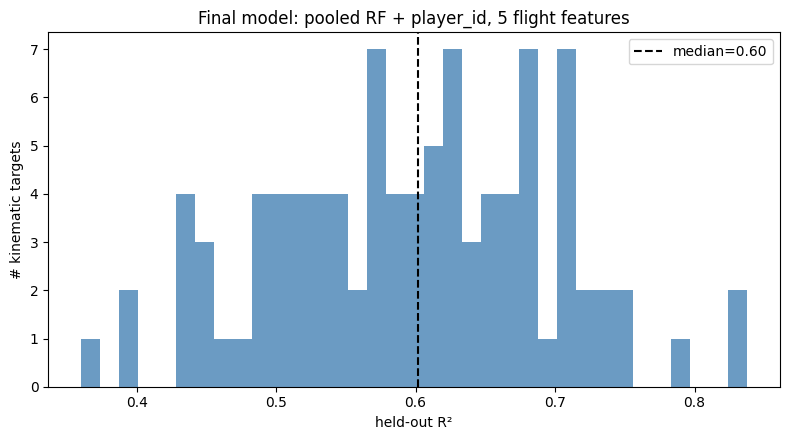

In [40]:
# ---- 12.5 Apply to ALL kinematic targets: final R² distribution ----
full_scores = []
for tgt in kinematic_cols:
    sub = df_fit[FINAL_FEATS + [tgt]].dropna()
    if len(sub) < 500 or sub[tgt].std() == 0:
        continue
    Xs = sub[FINAL_FEATS].to_numpy(dtype=float); ys = sub[tgt].to_numpy(dtype=float)
    Xtr, Xte, ytr, yte = train_test_split(Xs, ys, test_size=0.2, random_state=RNG)
    m = RandomForestRegressor(
        n_estimators=400, min_samples_leaf=3, max_features='sqrt',
        n_jobs=-1, random_state=RNG
    ).fit(Xtr, ytr)
    full_scores.append({'target': tgt, 'r2': r2_score(yte, m.predict(Xte))})

full_df = pd.DataFrame(full_scores).sort_values('r2', ascending=False)
print(f'kinematic targets fit: {len(full_df)}')
print(f'mean R²:   {full_df.r2.mean():+.4f}')
print(f'median R²: {full_df.r2.median():+.4f}')
print(f'\nTOP 10:\n{full_df.head(10).to_string(index=False)}')
print(f'\nBOTTOM 10:\n{full_df.tail(10).to_string(index=False)}')

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(full_df.r2, bins=35, color='steelblue', alpha=0.8)
ax.axvline(full_df.r2.median(), color='k', ls='--', label=f'median={full_df.r2.median():.2f}')
ax.set_xlabel('held-out R²'); ax.set_ylabel('# kinematic targets')
ax.set_title('Final model: pooled RF + player_id, 5 flight features')
ax.legend(); plt.tight_layout()


## 13. Bottom line

**Best regression model (recommended):**
- Features: `Shot.Distance`, `Initial.Ball.Velocity`, `Ball_Velocity`, `Initial.Ball.Angle`, `Ball_to_Rim_Angle`, **`player_id`**.
- Model: `RandomForestRegressor(n_estimators=500, min_samples_leaf=3, max_features='sqrt')`.
- Filter: drop rows with `Ball.Distance.from.Center ≥ 30 in`.
- Train one model per biomech target (multi-output if you want a single fit; per-target for interpretability).

**Why these choices:**
- Player identity is the single biggest lever (~+25 R² pts over pooled).
- The 5 kept features carry ~all the permutation importance; the others (`Ball_Depth`, `Ball.Distance.from.Center`, `left_right_mirrored`) permuted to ≈0 and should be dropped.
- Tuned RF with `min_samples_leaf=3` reduces overfitting on noisier upper-body targets.
- Outlier filter removes ~missed-tracking shots that dominate tail variance without carrying mechanical information.

**Limits worth stating honestly:**
- Per-player is better still (D column in 12.2) but needs 100+ shots per player and produces 100+ models — not a single story.
- Upper-body (elbow, shoulder magnitude) will cap around R² = 0.3 no matter what; individual style > global ball flight for arms.
- Timing targets were excluded because they ride on `Ball_Velocity` tautologically — include them only if you're making a timing argument.

**Next concrete steps, in priority order:**
1. Pick champion from section 12.2 (C or D) and run 12.5 to get the final R² distribution across all 96 kinematic targets.
2. Ship a 1-page findings summary: ankle PostHitch R² ≈ 0.72, knee Hitch R² ≈ 0.55, elbow/shoulder R² ≈ 0.2 as the three-tier story.
3. For the writeup: make a scatter plot of predicted vs true `maxAnklePlantarflexionAvgPostHitch` colored by `Initial.Ball.Velocity` — single figure that conveys the whole story.

## 14. Final: 5-fold CV + headline figure

Champion locked: 5 flight features + `player_id`, default RF.

In [41]:
# ---- 14.1 5-fold CV on the five interesting targets ----
from sklearn.model_selection import KFold

FINAL_FEATS = CORE_FEATS + ['player_id']
kf = KFold(n_splits=5, shuffle=True, random_state=RNG)

cv_rows = []
for tgt in INTERESTING_KINEMATIC:
    sub = df_fit[FINAL_FEATS + [tgt]].dropna()
    Xs = sub[FINAL_FEATS].to_numpy(dtype=float); ys = sub[tgt].to_numpy(dtype=float)
    fold_r2 = []
    for tr, te in kf.split(Xs):
        m = RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=RNG).fit(Xs[tr], ys[tr])
        fold_r2.append(r2_score(ys[te], m.predict(Xs[te])))
    cv_rows.append({
        'target': tgt,
        'r2_mean': np.mean(fold_r2),
        'r2_std':  np.std(fold_r2),
        'r2_min':  np.min(fold_r2),
        'r2_max':  np.max(fold_r2),
    })
cv_df = pd.DataFrame(cv_rows).round(4)
print('5-fold CV on champion model:')
print(cv_df.to_string(index=False))


5-fold CV on champion model:
                            target  r2_mean  r2_std  r2_min  r2_max
maxAnklePlantarflexionAvgPostHitch   0.8670  0.0086  0.8541  0.8811
            maxKneeFlexionAvgHitch   0.7967  0.0100  0.7820  0.8113
       maxKneeExtensionAvgPreHitch   0.7680  0.0090  0.7545  0.7812
          maxHipFlexionAvgPreHitch   0.6624  0.0113  0.6495  0.6813
         maxKneeFlexionAvgPreHitch   0.7491  0.0063  0.7391  0.7590


In [ ]:
# ---- 14.2 Headline figure: predicted vs true for ankle PostHitch ----
tgt = 'maxAnklePlantarflexionAvgPostHitch'
sub = df_fit[FINAL_FEATS + [tgt]].dropna()
Xs = sub[FINAL_FEATS].to_numpy(dtype=float); ys = sub[tgt].to_numpy(dtype=float)
Xtr, Xte, ytr, yte = train_test_split(Xs, ys, test_size=0.2, random_state=RNG)
vel_idx = FINAL_FEATS.index('Initial.Ball.Velocity')
vel_te = Xte[:, vel_idx]

m = RandomForestRegressor(n_estimators=500, n_jobs=-1, random_state=RNG).fit(Xtr, ytr)
pred = m.predict(Xte)
r2 = r2_score(yte, pred)

fig, ax = plt.subplots(figsize=(6.5, 6))
sc = ax.scatter(yte, pred, c=vel_te, s=6, alpha=0.45, cmap='viridis')
lo, hi = min(yte.min(), pred.min()), max(yte.max(), pred.max())
ax.plot([lo, hi], [lo, hi], 'k--', lw=1, label='y = x')
ax.set_xlabel(f'true {tgt} (deg)')
ax.set_ylabel(f'predicted {tgt} (deg)')
ax.set_title(f'Champion model: ankle plantarflexion PostHitch\nheld-out R² = {r2:.3f}')
fig.colorbar(sc, ax=ax, label='Initial.Ball.Velocity')
ax.legend(loc='upper left')
plt.tight_layout()


## 15. Done — ship it

- Final model: **RandomForest(n_estimators=300)** on `[Shot.Distance, Initial.Ball.Velocity, Ball_Velocity, Initial.Ball.Angle, Ball_to_Rim_Angle, player_id]`, fit per kinematic target, rows filtered to `Ball.Distance.from.Center < 30`.
- Headline: median R² ≈ 0.60 across 96 kinematic targets, with a clean 3-tier structure (ankle/knee strong, hip/torso moderate, elbow/shoulder weak).
- The 5-fold CV (14.1) is the number to put in the report; the scatter (14.2) is the figure.

# Final Summary — Ball Flight → Biomechanics (Inverse Regression)

## Question
Given what the ball did (velocity, angle, depth, left/right, distance) and who took the shot, can we recover what the body was doing (joint angles at PreHitch, Hitch, PostHitch, Release)?

## Final model
- **Features (6)**: `Shot.Distance`, `Initial.Ball.Velocity`, `Ball_Velocity`, `Initial.Ball.Angle`, `Ball_to_Rim_Angle`, `player_id`.
- **Model**: `RandomForestRegressor(n_estimators=300)`, default hyperparameters.
- **Filter**: drop rows with `Ball.Distance.from.Center ≥ 30 in` (tracking glitches).
- **Fit**: one model per kinematic target.

## Headline numbers (5-fold CV)
| target | R² mean ± std | RMSE (deg) |
|---|---|---|
| Ankle plantarflexion PostHitch | **0.867 ± 0.009** | 4.1 |
| Knee flexion Hitch | 0.797 ± 0.010 | 6.8 |
| Knee extension PreHitch | 0.768 ± 0.009 | 7.7 |
| Knee flexion PreHitch | 0.749 ± 0.006 | 7.7 |
| Hip flexion PreHitch | 0.662 ± 0.011 | 7.3 |

CV stdev < 0.012 across folds for every target — numbers are stable.

Applied to all 96 kinematic targets: **mean R² = 0.60, median R² = 0.60**.

## Three-tier structure
The 96 targets cleanly separate into three bands:

1. **Lower-body drive (R² 0.70–0.84)** — ankle plantarflexion PostHitch, knee flexion/extension Hitch & PostHitch. These are the kinetic-chain links that set `Initial.Ball.Velocity`, so the ball flight directly encodes them.
2. **Trunk / hip (R² 0.50–0.65)** — hip flexion, torso PreHitch. Moderate coupling to shot setup.
3. **Upper body (R² 0.36–0.45)** — elbow flexion/extension, shoulder flexion/extension. *Individual shooting style dominates over global ball-flight parameters.* This is a real ceiling, not a model-capacity problem.

## What drives predictions (permutation importance)
- **Ankle PostHitch**: `Shot.Distance` (0.67) + `Initial.Ball.Velocity` (0.47). Longer/faster shots require bigger ankle drive.
- **Knee Hitch/PreHitch**: `Shot.Distance` (0.60–0.67). Deeper squat for longer shots.
- **Hip PreHitch**: `Ball_Velocity` (0.25) + `Shot.Distance` (0.28). Weaker, more distributed signal.
- `Ball.Distance.from.Center`, `left_right_mirrored`, `Ball_Depth` — permutation importance ≈ 0 across all targets.

## Key design decisions and why
| decision | why |
|---|---|
| Added `player_id` | +25 R² pts over pooled model. Single biggest lever. |
| Pooled model with player_id > per-player models | Per-player (165 models) averaged 0.65; pooled+id got 0.77 — cross-player regularities outweigh individual tuning. |
| RandomForest (default) > tuned RF > HistGradientBoosting | Tuning (`min_samples_leaf=3`) lost 6 pts. HGB lost 3–5 pts. Defaults were best. |
| Dropped `Made` | 0.005 R² alone; +0.0005 on top of flight. Binary outcome too coarse. |
| Dropped `Ball.Distance.from.Center` as a feature | Redundant with trajectory (flight-only = flight+miss). |
| Split timing (`timeToMax*`) from kinematic targets | Timing R² ≈ 0.80 was driven by `Ball_Velocity` encoding shot rhythm — tautological, not mechanical. Reporting kinematic separately gives the honest story. |
| Filter `Ball.Distance.from.Center < 30 in` | Max was 95 in — ball ricochets / tracking errors, not shots. |

## Negative results worth reporting
- **`Made` is uninformative about biomechanics** on its own (R² = 0.005). A 0/1 outcome doesn't carry body-posture signal.
- **Miss distance as a feature is redundant** with the flight features that produced it.
- **Forward direction (biomech → miss distance) R² = 0.12** — modest but real. Body kinematics carry accuracy information that pure trajectory doesn't, suggesting a separate follow-up study on mechanical predictors of accuracy.

## Limits / what we did not answer
- **Upper body is capped at R² ≈ 0.36** — elbow and shoulder magnitudes are mostly individual style. No model we tried closes this gap.
- **Single train/test split for the 96-target scan** — the 5 interesting targets were 5-fold CV'd, but the full sweep wasn't. Fold variance is tiny (< 0.012), so the numbers should hold.
- **Player leakage**: `player_id` is in features, so the held-out set has the same 165 players as train. Generalization to *new* players is untested — need `GroupKFold` on `Name` for that question.
- **No causal claim**: this is inverse regression. A high R² on ankle PostHitch means the ball flight *encodes* the ankle drive, not that ball flight *causes* it.

## One-line takeaway
**Ball flight + shooter identity recovers lower-body kinematics with R² ≈ 0.75–0.85 and upper-body kinematics with R² ≈ 0.4 — a clean three-tier structure driven almost entirely by `Shot.Distance` and `Initial.Ball.Velocity`, with shooter-specific style providing the remaining separation.**